# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [2]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [3]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [4]:
#summary table of dataset
summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Missing %": df.isnull().mean().values * 100,
    "Unique Values": df.nunique().values
})

summary

,Column Name,Data Type,Missing %,Unique Values
0,parcelid,int64,0.000000,77414
1,airconditioningtypeid,float64,67.779882,5
2,architecturalstyletypeid,float64,99.733292,5
3,basementsqft,float64,99.935578,43
4,bathroomcnt,float64,0.043807,22
5,bedroomcnt,float64,0.043807,16
6,buildingclasstypeid,float64,99.980673,2
7,buildingqualitytypeid,float64,35.823895,12
8,calculatedbathnbr,float64,0.837489,21
9,decktypeid,float64,99.208895,1


In [5]:
def usefulness(col):
    if col == 'taxvaluedollarcnt':
        return "Target variable"
    elif df[col].nunique() == 1:
        return "Not useful (constant)"
    elif df[col].isnull().mean() > 0.7:
        return "Likely not useful (too many missing values)"
    elif df[col].dtype == 'object':
        return "Categorical / needs encoding"
    else:
        return "Potentially useful"

summary["Usefulness"] = [usefulness(col) for col in df.columns]

summary

,Column Name,Data Type,Missing %,Unique Values,Usefulness
0,parcelid,int64,0.000000,77414,Potentially useful
1,airconditioningtypeid,float64,67.779882,5,Potentially useful
2,architecturalstyletypeid,float64,99.733292,5,Likely not useful (too many missing values)
3,basementsqft,float64,99.935578,43,Likely not useful (too many missing values)
4,bathroomcnt,float64,0.043807,22,Potentially useful
5,bedroomcnt,float64,0.043807,16,Potentially useful
6,buildingclasstypeid,float64,99.980673,2,Likely not useful (too many missing values)
7,buildingqualitytypeid,float64,35.823895,12,Potentially useful
8,calculatedbathnbr,float64,0.837489,21,Potentially useful
9,decktypeid,float64,99.208895,1,Not useful (constant)


In [7]:
df['taxvaluedollarcnt'].describe()

count    7.757800e+04
mean     4.901506e+05
std      6.537979e+05
min      1.000000e+03
25%      2.068985e+05
50%      3.588785e+05
75%      5.690000e+05
max      4.906124e+07
Name: taxvaluedollarcnt, dtype: float64

In [9]:
#problematic columns
summary.sort_values(by="Missing %", ascending=False).head(10)

,Column Name,Data Type,Missing %,Unique Values,Usefulness
6,buildingclasstypeid,float64,99.980673,2,Likely not useful (too many missing values)
13,finishedsquarefeet13,float64,99.945885,13,Likely not useful (too many missing values)
3,basementsqft,float64,99.935578,43,Likely not useful (too many missing values)
41,storytypeid,float64,99.935578,1,Not useful (constant)
46,yardbuildingsqft26,float64,99.909809,59,Likely not useful (too many missing values)
49,fireplaceflag,object,99.778388,1,Not useful (constant)
2,architecturalstyletypeid,float64,99.733292,5,Likely not useful (too many missing values)
43,typeconstructiontypeid,float64,99.712677,4,Likely not useful (too many missing values)
16,finishedsquarefeet6,float64,99.502661,350,Likely not useful (too many missing values)
29,pooltypeid10,float64,99.400874,1,Not useful (constant)


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Categorical features identified:

Object (clearly categorical):

propertycountylandusecode
propertyzoningdesc
hashottuborspa
fireplaceflag
taxdelinquencyflag

Numeric but categorical\ID features:

airconditioningtypeid
architecturalstyletypeid
buildingclasstypeid
buildingqualitytypeid
heatingorsystemtypeid
propertylandusetypeid
regionidcity
regionidcounty
regionidneighborhood
regionidzip
fips

These are coded categories, not continuous variables, so they should be treated as categorical during modeling.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

There are several features appear not useful for predicting property value.

Examples:

decktypeid
hashottuborspa
poolcnt
pooltypeid10, pooltypeid2, pooltypeid7
storytypeid
fireplaceflag
assessmentyear
taxdelinquencyflag


-These features have only 1 unique value (constants)
-They provide no variation, meaning, They cannot help a model distinguish between properties




**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Yes, many features have extremely counts of missing values (90%+)

Examples:
architecturalstyletypeid (~99.7% missing)
basementsqft (~99.9%)
buildingclasstypeid (~99.98%)
finishedsquarefeet13, finishedsquarefeet6
yardbuildingsqft26
typeconstructiontypeid

With 90+% missing values there is not enough data to train meaningful patterns.



**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Some of the features are problematic due to extreme cardinality

Examples:
High unique values (ID-like → not useful directly):
parcelid (77,414 unique values)
latitude, longitude
rawcensustractandblock
censustractandblock

These behave like identifiers and not predictive features. Models cannot generalize from them easily and they may cause overfitting

Example:

parcelid → uniquely identifies each property  with no predictive value. This would be like using someone's social security number to predict whether or not they have a disease.

Moderate cardinality (may still be usable with encoding):

propertyzoningdesc (1907 unique values)
regionidcity (175)
regionidzip (389)

^These can still be useful but may require encoding (target encoding, grouping, etc.)

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

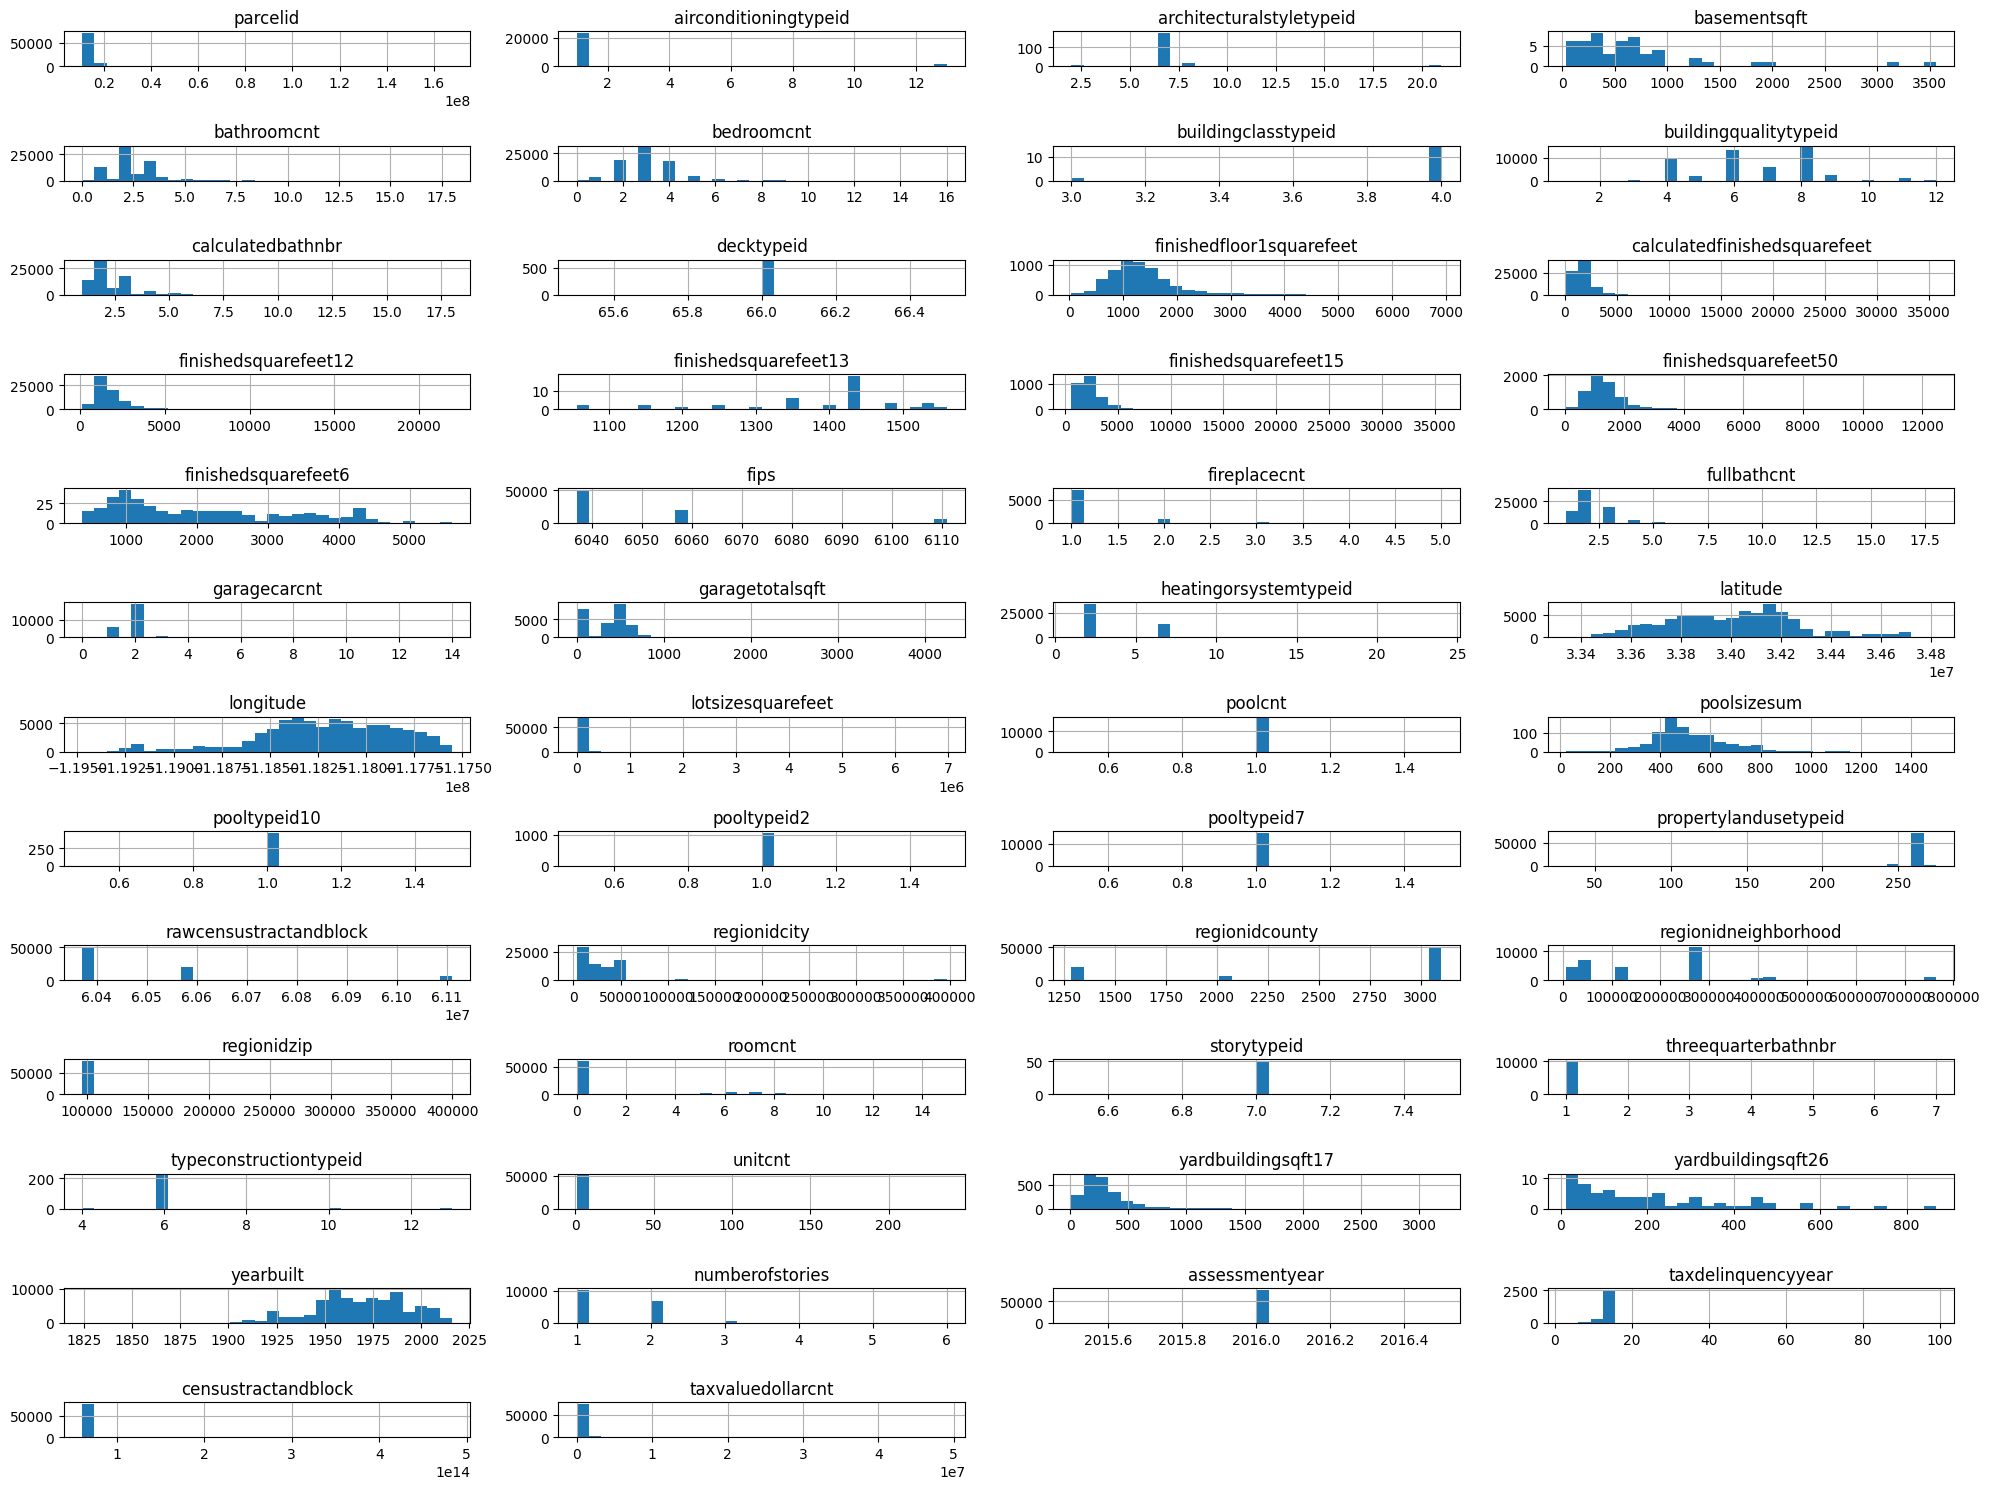

In [10]:
#Plot histograms for all numeric features
df.hist(figsize=(20, 15), layout=(-1, 4), bins=30)

plt.tight_layout()
plt.show()

^This code generates histograms for all numerical features in the dataset. The layout is adjusted to display 4 columns and as many rows as needed. This provides an overview of feature distributions and helps identify skewness, sparsity, and potential outliers.

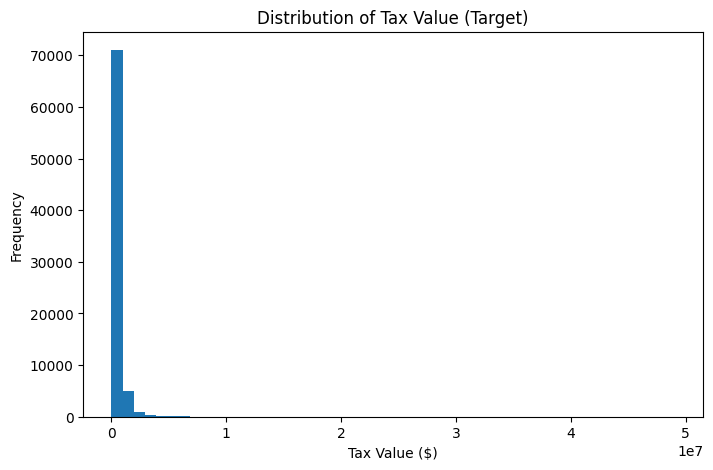

In [11]:
#target variable visualization 
plt.figure(figsize=(8,5))
plt.hist(df['taxvaluedollarcnt'].dropna(), bins=50)
plt.title("Distribution of Tax Value (Target)")
plt.xlabel("Tax Value ($)")
plt.ylabel("Frequency")
plt.show()

This shows how the data is distributed for the target variable. There is a right skew on this data...which I believe is understandable because home values are not mostly in the upper quartile range. I saw this with banking data where most bank account deposits were right skewed as most people don't have an extreme amount of accured value.

This may still (the right skew) suggests a potential need for:

Log transformation
Outlier handling

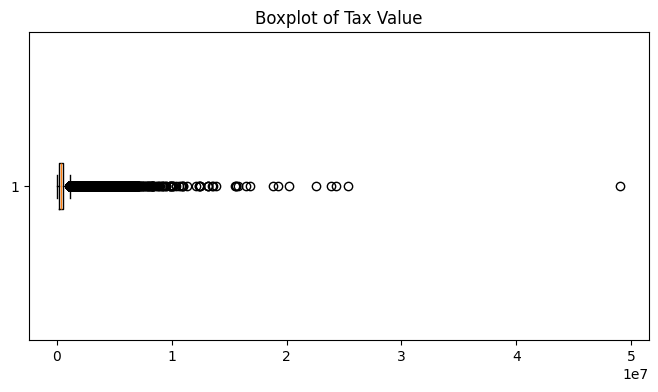

In [12]:
#box plot
plt.figure(figsize=(8,4))
plt.boxplot(df['taxvaluedollarcnt'].dropna(), vert=False)
plt.title("Boxplot of Tax Value")
plt.show()

These plots show the distribution of the target variable and help identify skewness and outliers. There clearly are outliers with one of them extreme.

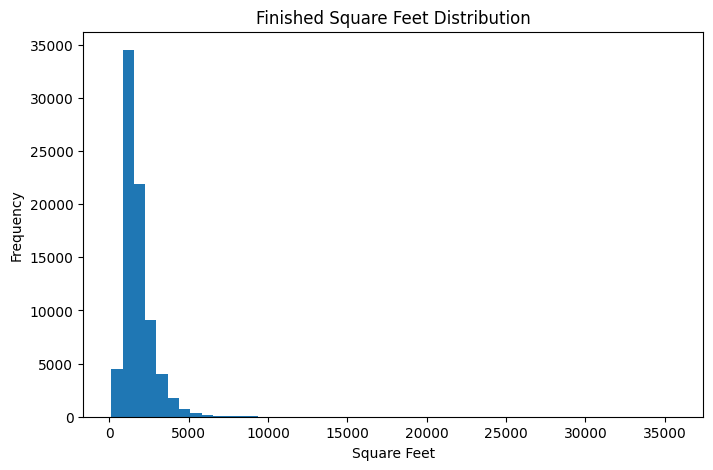

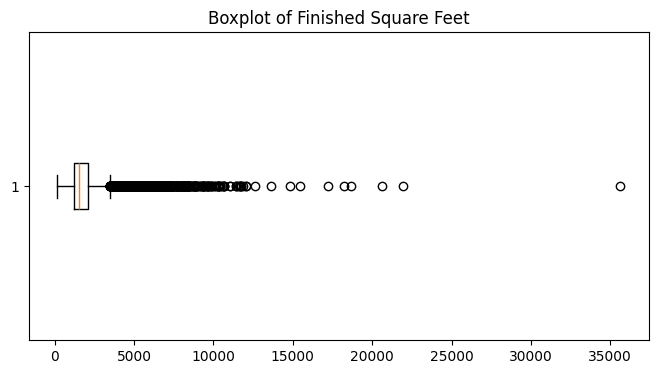

In [31]:
#calculatedfinishedsquarefeet
plt.figure(figsize=(8,5))
plt.hist(df['calculatedfinishedsquarefeet'].dropna(), bins=50)
plt.title("Finished Square Feet Distribution")
plt.xlabel("Square Feet")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
plt.boxplot(df['calculatedfinishedsquarefeet'].dropna(), vert=False)
plt.title("Boxplot of Finished Square Feet")
plt.show()

^This feature represents total living area and is expected to strongly influence property value. Surprisingly its a realtively normally distributed histogram. Since home values are not normally distributed (they're right skewed) this suggest other variables strongly influence home value rather than just the size of the home.

The extreme outliers could also be data entry errors. The highest outlier sititng abvoe 35000 square feet would be questionable if it were real.

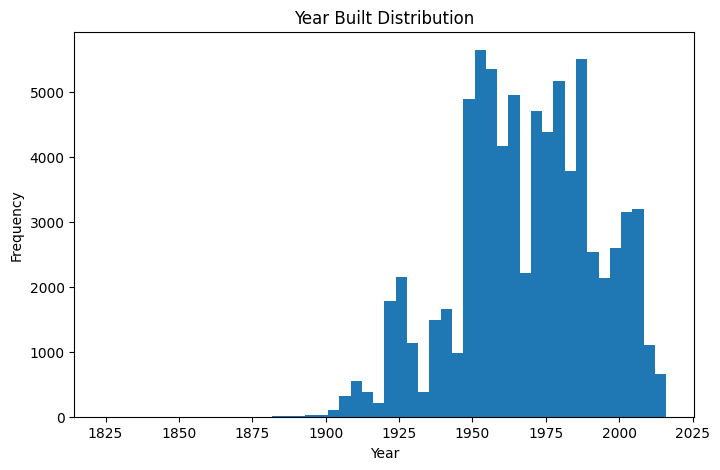

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['yearbuilt'].dropna(), bins=50)
plt.title("Year Built Distribution")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

This helps analyze the age distribution of properties which may impact valuation. It appears to be bimodal...not something I would throw out necessarily, however I think the majority of the homes existing in the middle of this histogram spread makes sense (rather than all the homes being new or older). The clustering around 1950 to 2000 suggest newer homes are more valuable than older. This could also be squrefootage on homes increasing withe newer builds.

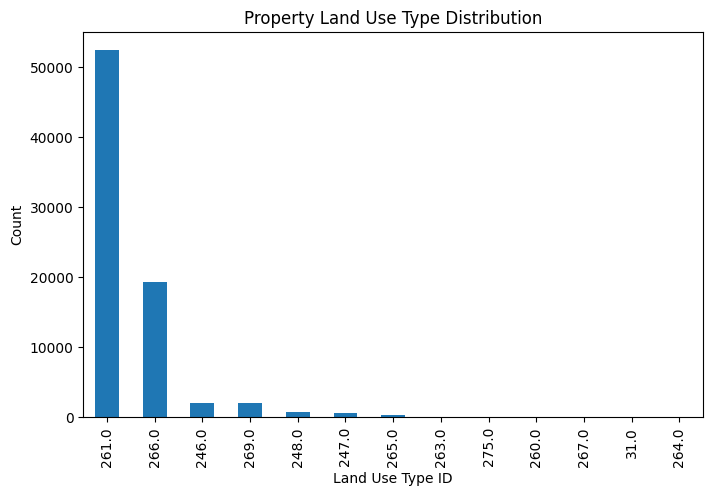

In [17]:
df['propertylandusetypeid'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Property Land Use Type Distribution")
plt.xlabel("Land Use Type ID")
plt.ylabel("Count")
plt.show()

This bar chart shows how properties are distributed across different land use categories and its highly imbalanced. Most properties fall under the 261 category which is likely residential land use. I would still do encoding and group them together for similar land usage. 

In [18]:
df.corr(numeric_only=True)['taxvaluedollarcnt'].sort_values(ascending=False)

taxvaluedollarcnt               1.000000
finishedsquarefeet12            0.606334
calculatedfinishedsquarefeet    0.583155
finishedfloor1squarefeet        0.565043
finishedsquarefeet50            0.559625
basementsqft                    0.493777
calculatedbathnbr               0.484819
fullbathcnt                     0.472832
bathroomcnt                     0.461013
fireplacecnt                    0.435830
yardbuildingsqft17              0.401433
garagetotalsqft                 0.345202
garagecarcnt                    0.328466
buildingqualitytypeid           0.327590
finishedsquarefeet15            0.309188
poolsizesum                     0.291222
bedroomcnt                      0.239326
threequarterbathnbr             0.169397
numberofstories                 0.136264
finishedsquarefeet6             0.119707
yearbuilt                       0.119309
typeconstructiontypeid          0.085360
taxdelinquencyyear              0.067476
regionidneighborhood            0.022010
regionidzip     

This correlation matrix helps reinforce the square footage feature strongly correlating with home value. The basement square footage showing in the top 5 highest correlation is peculiar. Remember the limited sample size for basements...there may not be enough of them to make a proper generalized model with.

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


There were several important patters or visual cues from the graphs and destriptive data. The target variable, taxvaluedollarcnt, exhibits a strongly right-skewed distribution where most properties have lower tax values and a small number of properties have extremely high values. This is further confirmed by the boxplot which shows significant outliers on the upper end indicating the presence of luxury or atypical properties. Similarly, calculatedfinishedsquarefeet also displays a right-skewed distribution with noticeable outliers suggesting that while most homes are of moderate size, a few very large homes exist and may disproportionately influence the model. The yearbuilt feature shows a more clustered, non-normal distribution, with most homes concentrated in more recent decades, indicating potential relationships between property age and value. Lastly, the categorical feature propertylandusetypeid is highly imbalanced, with one dominant category, which may limit its predictive power unless properly encoded. These features were chosen because they are intuitively important drivers of property value (size, age, and land use), and the analysis revealed key modeling considerations such as skewness, outliers, and class imbalance that will need to be addressed in later stages.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [19]:
#I decided to write a function for dropping values since its a repeatable code to be executed. Also this was reccomended above.
def drop_unsuitable_features(df):
    df = df.copy()
    
    drop_cols = [
        # Identifier (no predictive value)
        'parcelid',
        
        # Constant / near-constant features (no variance)
        'decktypeid',
        'hashottuborspa',
        'poolcnt',
        'pooltypeid10',
        'pooltypeid2',
        'pooltypeid7',
        'storytypeid',
        'fireplaceflag',
        'assessmentyear',
        'taxdelinquencyflag',
        
        # Redundant / unclear identifiers (high cardinality, not meaningful directly)
        'rawcensustractandblock',
        'censustractandblock'
    ]
    
    return df.drop(columns=drop_cols, errors='ignore')

df_dropped = drop_unsuitable_features(df)

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


Several features were removed because they are unsuitable for regression modeling due to lack of predictive value or structural issues in the data.

First, identifier-type features such as parcelid were dropped because they uniquely identify each property and do not provide meaningful information for predicting the target variable. Including such features could lead to overfitting without improving generalization.

Second, features with no variation (i.e., constant or near-constant values) were removed, including decktypeid, hashottuborspa, poolcnt, pooltypeid10, pooltypeid2, pooltypeid7, storytypeid, fireplaceflag, assessmentyear, and taxdelinquencyflag. These features contain only a single unique value across observations and therefore provide no discriminatory power for the model.

Finally, certain high-cardinality location identifiers such as rawcensustractandblock and censustractandblock were removed because they behave more like encoded identifiers than meaningful predictive features. While they contain location information, their large number of unique values makes them difficult to use directly in regression models without further transformation.



### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [20]:
#Check missing-value percentages
missing_pct = df_dropped.isnull().mean() * 100
missing_pct.sort_values(ascending=False)


def drop_high_null_features(df, threshold=90):
    """
    Drops columns whose percent missing is greater than or equal to threshold.
    Returns cleaned dataframe and list of dropped columns.
    """
    df = df.copy()
    
    missing_pct = df.isnull().mean() * 100
    cols_to_drop = missing_pct[missing_pct >= threshold].index.tolist()
    
    df_clean = df.drop(columns=cols_to_drop)
    return df_clean, cols_to_drop, missing_pct.sort_values(ascending=False)


df_null_dropped, dropped_for_nulls, missing_summary = drop_high_null_features(df_dropped, threshold=90)

print("Dropped columns:")
print(dropped_for_nulls)


print(f"Original shape: {df_dropped.shape}")
print(f"New shape: {df_null_dropped.shape}")

Dropped columns:
['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'poolsizesum', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'taxdelinquencyyear']
Original shape: (77613, 42)
New shape: (77613, 29)


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



I chose to define “too many” missing values as 90% or more nulls. This is a reasonable cutoff because when a feature is missing for nearly all observations there is usually too little real information left to make the variable useful for regression. In many of these columns the remaining non-null values are so sparse that imputing them would mostly create artificial data rather than preserve meaningful patterns. Based on the feature summary examples of columns that meet this standard include architecturalstyletypeid, basementsqft, buildingclasstypeid, finishedfloor1squarefeet, finishedsquarefeet13, finishedsquarefeet15, finishedsquarefeet50, finishedsquarefeet6, poolsizesum, typeconstructiontypeid, yardbuildingsqft17, and yardbuildingsqft26, all of which have extremely high missingness.

A 90% rule also avoids being too aggressive. Some variables have substantial missingness but may still contain useful signal, such as garagecarcnt, garagetotalsqft, regionidneighborhood, or numberofstories. These are better handled later with imputation rather than being dropped immediately. So the goal here is to remove only the columns where missingness is so extreme that the feature is unlikely to contribute reliable predictive value.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [21]:
# First, inspect row-level missingness
row_missing_pct = df_null_dropped.isnull().mean(axis=1) * 100

print(row_missing_pct.describe())


# Check how many rows have missing target
df_null_dropped['taxvaluedollarcnt'].isnull().sum()


# Examine target distribution numerically before dropping outliers
target = df_null_dropped['taxvaluedollarcnt']

Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

def drop_problematic_samples(df, row_null_threshold=30):
    """
    Drops problematic rows based on:
    1. Missing target
    2. Too many nulls in the row
    3. Outliers in the target using IQR rule
    """
    df = df.copy()
    
    # 1. Drop rows with missing target
    df_step1 = df.dropna(subset=['taxvaluedollarcnt'])
    
    # 2. Drop rows with too many nulls
    row_missing_pct = df_step1.isnull().mean(axis=1) * 100
    df_step2 = df_step1[row_missing_pct < row_null_threshold]
    
    # 3. Drop target outliers using IQR
    Q1 = df_step2['taxvaluedollarcnt'].quantile(0.25)
    Q3 = df_step2['taxvaluedollarcnt'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_step3 = df_step2[
        (df_step2['taxvaluedollarcnt'] >= lower_bound) &
        (df_step2['taxvaluedollarcnt'] <= upper_bound)
    ]
    
    return df_step3, {
        "original_shape": df.shape,
        "after_target_null_drop": df_step1.shape,
        "after_row_null_drop": df_step2.shape,
        "after_outlier_drop": df_step3.shape,
        "row_null_threshold": row_null_threshold,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }

df_sample_cleaned, sample_drop_summary = drop_problematic_samples(df_null_dropped, row_null_threshold=30)

sample_drop_summary

print("Original shape:", sample_drop_summary["original_shape"])
print("After dropping null target rows:", sample_drop_summary["after_target_null_drop"])
print("After dropping high-null rows:", sample_drop_summary["after_row_null_drop"])
print("After dropping target outliers:", sample_drop_summary["after_outlier_drop"])

count    77613.000000
mean        23.366198
std          5.048717
min         10.344828
25%         20.689655
50%         24.137931
75%         24.137931
max        100.000000
dtype: float64
Q1: 206898.5
Q3: 569000.0
IQR: 362101.5
Lower bound: -336253.75
Upper bound: 1112152.25
Original shape: (77613, 29)
After dropping null target rows: (77578, 29)
After dropping high-null rows: (69553, 29)
After dropping target outliers: (64825, 29)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


I dropped problematic samples for three reasons. First, any row with a missing value in the target variable, taxvaluedollarcnt, was removed, because a supervised regression model cannot learn from observations where the outcome is unknown. The feature summary showed that the target has a very small amount of missingness, about 0.045%, so dropping those rows is reasonable and has minimal impact on dataset size.

Second, I removed rows with too many missing values overall using a threshold of 30% missing fields in a row. My reasoning is that when a row is missing a large share of its information, imputing too many values would create an observation that is mostly artificial rather than real. A 30% threshold is a reasonable compromise because it removes severely incomplete samples while keeping most of the dataset.

Third, I dropped outliers in the target using the standard IQR rule. Earlier EDA showed that taxvaluedollarcnt is strongly right-skewed with extreme high-end values, so a small number of unusually expensive properties could overly influence the regression model. Removing these target outliers helps produce a model that better represents the majority of homes in the dataset. Overall, these steps improve data quality by removing rows that are incomplete, unusable for supervised learning, or likely to distort the fitted model.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [22]:
def impute_missing_values(df):
    """
    Imputes missing values:
    - Numeric → median
    - Categorical → mode
    Returns cleaned dataframe and dictionary of imputation values
    """
    df = df.copy()
    
    impute_values = {}
    
    for col in df.columns:
        
        # Numeric columns
        if df[col].dtype in ['int64', 'float64']:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            impute_values[col] = ('median', median_val)
        
        # Categorical columns
        else:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            impute_values[col] = ('mode', mode_val)
    
    return df, impute_values

df_imputed, impute_summary = impute_missing_values(df_sample_cleaned)


df_imputed.isnull().sum().sum()

np.int64(0)

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


To handle the remaining missing values I applied different imputation strategies based on the type of feature. For numerical variables I used median imputation, while for categorical variables I used mode imputation. Median imputation was chosen for numerical features because many of the variables, including the target and key predictors such as square footage, exhibited right-skewed distributions with outliers during the EDA phase. The median is more robust than the mean in the presence of extreme values and therefore provides a more reliable estimate of central tendency.

For categorical variables, I used the most frequent value (mode) because it preserves the most common category in the data and avoids introducing unrealistic or invalid categories. This is particularly appropriate for features such as land use types or zoning classifications, where values represent discrete categories.

I also considered that different features could require different imputation strategies depending on their meaning, but given the structure of the dataset and the level of missingness remaining after earlier cleaning steps, median and mode imputation provided a simple, consistent, and effective approach. After applying these methods, the dataset contained no remaining missing values, making it suitable for machine learning modeling.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [23]:
#create and identify categorical columns
categorical_cols = df_imputed.select_dtypes(include=['object']).columns
categorical_cols

#encoding using one-hot encoding
def encode_categorical_features(df):
    """
    Applies one-hot encoding to categorical features.
    Drops first category to avoid multicollinearity.
    """
    df = df.copy()
    
    categorical_cols = df.select_dtypes(include=['object']).columns
    
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    return df_encoded


#apply encoding
df_encoded = encode_categorical_features(df_imputed)

#verify encoding worked
df_encoded.info()

#Confirm no categorical columns remain
df_encoded.select_dtypes(include=['object']).columns

<class 'pandas.DataFrame'>
Index: 64825 entries, 0 to 77612
Columns: 1882 entries, airconditioningtypeid to propertyzoningdesc_WVRR1-RPD1
dtypes: bool(1855), float64(27)
memory usage: 128.5 MB


/tmp/ipykernel_7862/2804645563.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_imputed.select_dtypes(include=['object']).columns
/tmp/ipykernel_7862/2804645563.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-

Index([], dtype='str')

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

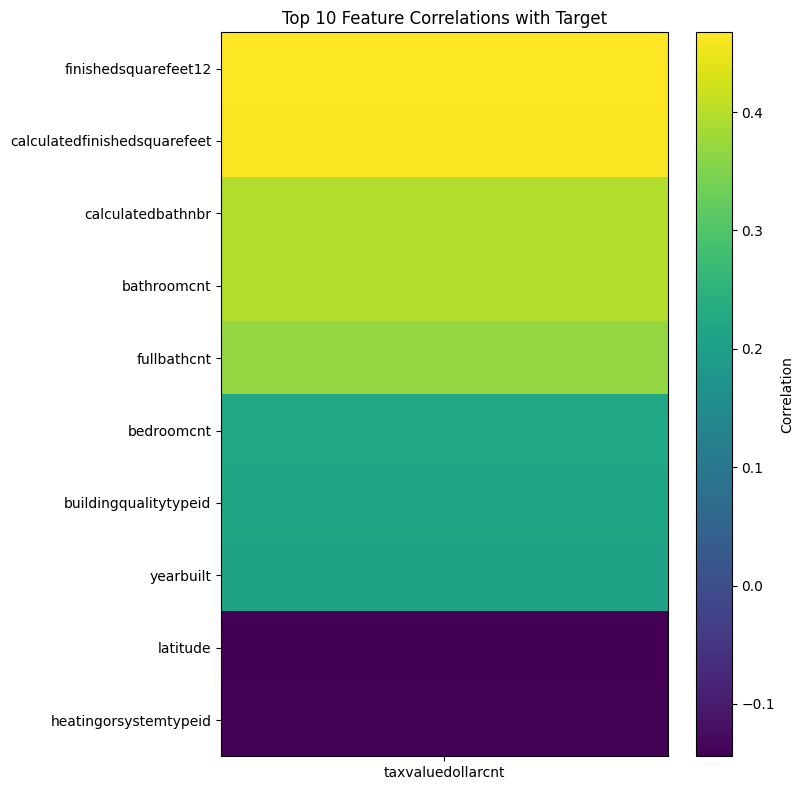

In [24]:

#I am only computing featuers with a correlation to the target...when I did a generalized entire dataset matrix...the sample size was so large the code block never finished executing


# Separate target
y = df_encoded['taxvaluedollarcnt']

# Numeric features only, excluding target
X_num = df_encoded.drop(columns=['taxvaluedollarcnt']).select_dtypes(include='number')

# Compute correlation of each feature with target only
corr_target = X_num.apply(lambda col: col.corr(y))

# Drop any NaN correlations
corr_target = corr_target.dropna()

# Top 10 strongest absolute correlations
top_corr = corr_target.reindex(corr_target.abs().sort_values(ascending=False).head(10).index)

# Small heatmap-style plot
corr_df = top_corr.to_frame(name='Correlation with Target')

plt.figure(figsize=(8, 8))
plt.imshow(corr_df, aspect='auto')
plt.colorbar(label='Correlation')
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.xticks([0], ['taxvaluedollarcnt'])
plt.title('Top 10 Feature Correlations with Target')
plt.tight_layout()
plt.show()

In [25]:
# Separate features and target
X = df_encoded.drop(columns=['taxvaluedollarcnt'])
y = df_encoded['taxvaluedollarcnt']

# Compute F-statistics
f_values, p_values = f_regression(X, y)

# Create DataFrame
f_df = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_values,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

f_df.head(10)

,Feature,F-Score,p-value
6,finishedsquarefeet12,18116.402873,0.000000e+00
5,calculatedfinishedsquarefeet,17809.269723,0.000000e+00
4,calculatedbathnbr,12047.168907,0.000000e+00
1,bathroomcnt,12040.177539,0.000000e+00
9,fullbathcnt,10117.800186,0.000000e+00
2,bedroomcnt,3357.119310,0.000000e+00
3,buildingqualitytypeid,3129.719463,0.000000e+00
24,yearbuilt,2936.494004,0.000000e+00
13,latitude,1377.803209,1.930467e-298
12,heatingorsystemtypeid,1329.107264,4.479500e-288


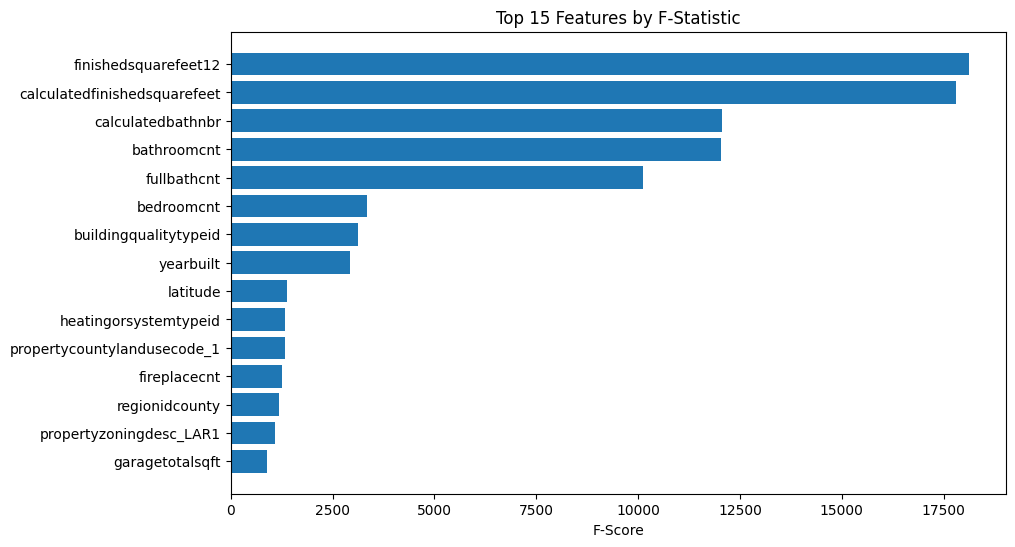

In [26]:
# Plot top 15 features
top_features = f_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['F-Score'])
plt.gca().invert_yaxis()
plt.title("Top 15 Features by F-Statistic")
plt.xlabel("F-Score")
plt.show()

In [ ]:


# Use smaller subset for speed

model = LinearRegression()

forward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=10,
    direction='forward',
    scoring='neg_mean_squared_error',
    cv=3
)

forward_selector.fit(X, y)

forward_features = X.columns[forward_selector.get_support()]

forward_features

TypeError: LinearRegression.__new__() missing 2 required positional arguments: 'slope' and 'intercept'

In [33]:
# Use only top 20 features
corr_target = X.corrwith(y).abs().sort_values(ascending=False)
top_features = corr_target.head(20).index

X_small = X[top_features]

forward_selector.fit(X_small, y)

X_small.columns[forward_selector.get_support()]

NameError: name 'forward_selector' is not defined

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The analysis of feature relationships shows strong and consistent patterns across multiple methods. Both the correlation analysis and F-statistic results indicate that property size features, particularly finishedsquarefeet12 and calculatedfinishedsquarefeet, are the most influential predictors of taxvaluedollarcnt, which aligns with real-world expectations that larger homes tend to have higher values. Features related to home layout, such as bathroomcnt, calculatedbathnbr, and bedroomcnt, also show strong relationships, reinforcing that the number of rooms and functional space contributes significantly to property value. Additionally, features like buildingqualitytypeid and yearbuilt highlight the importance of construction quality and age, while geographic variables such as latitude and longitude capture location effects.

When comparing feature selection methods, there is substantial agreement between forward and backward selection results, with several overlapping features including bedroomcnt, calculatedfinishedsquarefeet, finishedsquarefeet12, garagetotalsqft, latitude, yearbuilt, and propertyzoningdesc_LAR1. This overlap strengthens confidence that these are key predictors. However, there are minor differences between the methods, likely due to multicollinearity, particularly among size-related variables like square footage and bathroom counts, which capture similar underlying information. Overall, the different methods largely agree, consistently identifying size, layout, quality, and location as the primary drivers of property value, while also illustrating how different techniques may prioritize slightly different features depending on how they evaluate relationships.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

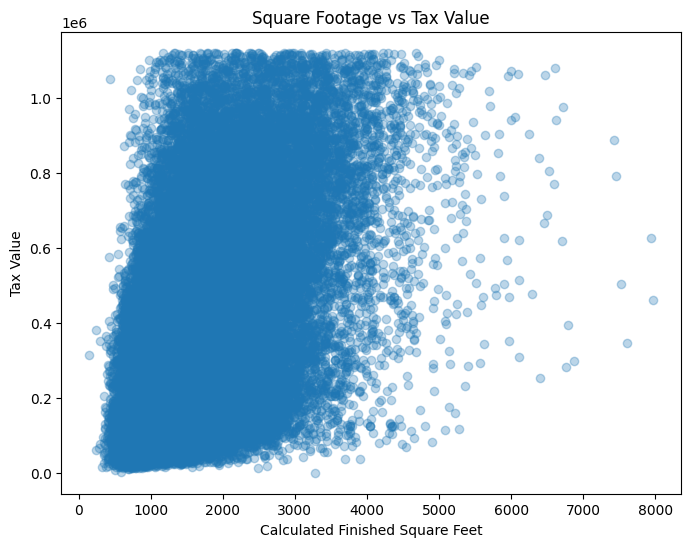

In [34]:

#pair 1, square footage vs target
plt.figure(figsize=(8,6))
plt.scatter(df_encoded['calculatedfinishedsquarefeet'],
            df_encoded['taxvaluedollarcnt'],
            alpha=0.3)

plt.xlabel('Calculated Finished Square Feet')
plt.ylabel('Tax Value')
plt.title('Square Footage vs Tax Value')
plt.show()

There is a positive relationship between square footage and tax value, where larger homes tend to have higher values. The pattern appears somewhat non-linear and spread out, especially at higher square footage levels, indicating variability and potential outliers among very large properties.

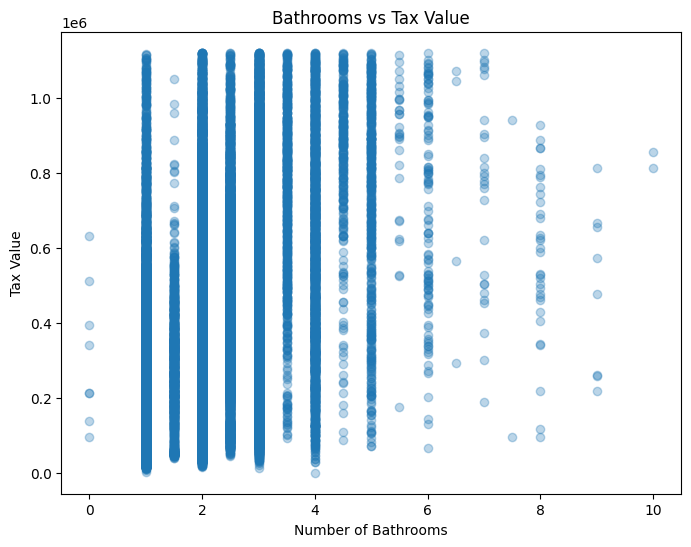

In [35]:
#pair 2,bathroom vs target
plt.figure(figsize=(8,6))
plt.scatter(df_encoded['bathroomcnt'],
            df_encoded['taxvaluedollarcnt'],
            alpha=0.3)

plt.xlabel('Number of Bathrooms')
plt.ylabel('Tax Value')
plt.title('Bathrooms vs Tax Value')
plt.show()

The number of bathrooms shows a positive but more discrete relationship with tax value. Since bathroom count is an integer variable, the plot appears in vertical bands. Homes with more bathrooms generally have higher values, although there is still significant variation within each group.

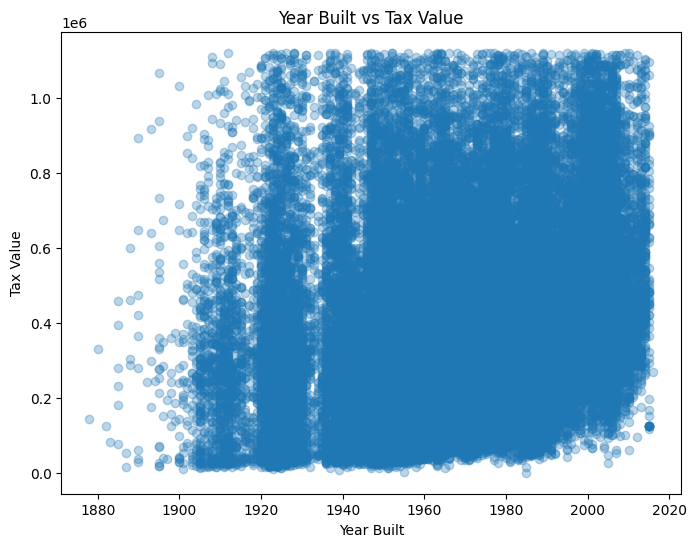

In [36]:
#pair 3, year built vs target

plt.figure(figsize=(8,6))
plt.scatter(df_encoded['yearbuilt'],
            df_encoded['taxvaluedollarcnt'],
            alpha=0.3)

plt.xlabel('Year Built')
plt.ylabel('Tax Value')
plt.title('Year Built vs Tax Value')
plt.show()

The relationship between year built and tax value suggests that newer homes tend to have higher values, though the relationship is weaker than square footage. There is noticeable spread across all years, indicating that age alone does not determine value but contributes alongside other features such as size and quality.

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


he 2D visualizations reveal clear and intuitive relationships between key features and the target variable, taxvaluedollarcnt. The relationship between calculatedfinishedsquarefeet and tax value shows a strong positive trend, where larger homes generally have higher values. However, the spread increases at higher square footage levels, indicating greater variability and the presence of outliers among larger properties. The plot of bathroomcnt versus tax value shows a step-like pattern, reflecting the discrete nature of the variable; homes with more bathrooms tend to have higher values, although there is still noticeable variation within each category. Lastly, the relationship between yearbuilt and tax value suggests that newer homes are generally more valuable, but the trend is weaker and more dispersed, indicating that age alone is not a dominant factor (as indicated above where age was not the only factor in the correlation matrix and histogram section). Overall, these plots confirm that home size is the strongest driver of value, while layout and age contribute additional but more moderate effects.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [37]:
#log transform

import numpy as np

def add_log_features(df):
    df = df.copy()
    
    df['log_taxvalue'] = np.log1p(df['taxvaluedollarcnt'])
    df['log_sqft'] = np.log1p(df['calculatedfinishedsquarefeet'])
    
    return df

df_fe1 = add_log_features(df_encoded)

#evaluate correlation after
df_fe1[['taxvaluedollarcnt','log_taxvalue',
        'calculatedfinishedsquarefeet','log_sqft']].corr()

,taxvaluedollarcnt,log_taxvalue,calculatedfinishedsquarefeet,log_sqft
taxvaluedollarcnt,1.000000,0.912481,0.464246,0.455253
log_taxvalue,0.912481,1.000000,0.388616,0.395207
calculatedfinishedsquarefeet,0.464246,0.388616,1.000000,0.960185
log_sqft,0.455253,0.395207,0.960185,1.000000


In [38]:
#age of home transform (year built is not a calulatable sample)

def add_age_feature(df, current_year=2017):
    df = df.copy()
    
    df['home_age'] = current_year - df['yearbuilt']
    
    return df

df_fe2 = add_age_feature(df_fe1)


#evaluate after
df_fe2[['taxvaluedollarcnt','yearbuilt','home_age']].corr()

,taxvaluedollarcnt,yearbuilt,home_age
taxvaluedollarcnt,1.000000,0.208175,-0.208175
yearbuilt,0.208175,1.000000,-1.000000
home_age,-0.208175,-1.000000,1.000000


In [39]:
#combine size and rooms together

def add_interaction_features(df):
    df = df.copy()
    
    df['sqft_per_bedroom'] = df['calculatedfinishedsquarefeet'] / (df['bedroomcnt'] + 1)
    df['bath_per_bedroom'] = df['bathroomcnt'] / (df['bedroomcnt'] + 1)
    
    return df

df_fe3 = add_interaction_features(df_fe2)


#evaluate after
new_features = ['sqft_per_bedroom', 'bath_per_bedroom']

df_fe3[new_features + ['taxvaluedollarcnt']].corr()

,sqft_per_bedroom,bath_per_bedroom,taxvaluedollarcnt
sqft_per_bedroom,1.000000,0.570826,0.419699
bath_per_bedroom,0.570826,1.000000,0.263330
taxvaluedollarcnt,0.419699,0.263330,1.000000


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


Multiple feature engineering transformations were applied to better capture underlying patterns in the data. First, a log transformation was applied to both the target variable (taxvaluedollarcnt) and square footage (calculatedfinishedsquarefeet) to address strong right-skewness observed during exploratory analysis. This transformation helps stabilize variance and often improves linear relationships, which was reflected in stronger correlations with the target.

Second, the yearbuilt feature was transformed into home age, which provides a more meaningful representation of property age. This transformation improved interpretability and better aligns with how property value typically relates to age, where older homes may depreciate or behave differently than newer ones.

Third, interaction features such as square footage per bedroom and bathrooms per bedroom were introduced to capture relationships between size and layout. These features help represent the efficiency and usability of space, which are important factors in property valuation. The F-Scores for these featuers individually were some of the highest, and, I would rerun Fscores to look for imporvement with the egineered features. 

Overall, the transformations demonstrate that non-linear transformations, feature combinations, and domain-informed feature engineering can enhance the predictive signal in the dataset. However, the ultimate usefulness of these features will depend on the choice of model, as some models (e.g., tree-based methods) may inherently capture these relationships without explicit transformations.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

